## Create Csv file with Elo Ratings for Coaches and Teams
Season, DayNum, TeamID, (CoachElo, TeamElo) (until DayNum.Season)
Save to data/elo.csv

# Teoria rankingu Elo

System Elo opiera się na modelu probabilistycznym, który zakłada, że wyniki rywalizacji można modelować za pomocą funkcji logistycznej.

Prawdopodobieństwo, że drużyna A (z rankingiem Elo $R_A$) pokona drużynę B (z rankingiem Elo $R_B$) jest dane wzorem:

$$
P(A) = \frac{1}{1 + 10^{\frac{R_B - R_A}{400}}}
$$

Analogicznie, prawdopodobieństwo, że drużyna B wygra, to:

$$
P(B) = 1 - P(A)
$$

Przykład: Jeśli drużyna ma ranking 2000, a przeciwnik 1800, to:

$$
\begin{aligned}
P(2000 \text{ wygrywa}) &= \frac{1}{1 + 10^{\frac{1800 - 2000}{400}}} \\
&= \frac{1}{1 + 10^{\frac{-200}{400}}} \\
&= \frac{1}{1 + 10^{-0.5}} \\
&\approx \frac{1}{1 + 0.316} \\
&\approx 0.76
\end{aligned}
$$

Oznacza to, że drużyna z ELO 2000 ma około 76% szans na zwycięstwo z drużyną o ELO 1800.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
elo_ratings = {}
def calculate_elo(df, k=32, initial_elo=1500):
    # Słownik przechowujący aktualne wartości ELO dla drużyn

    # Lista do przechowywania wynikowej ramki danych
    elo_history = []

    for (season, day), games in df.groupby(['Season', 'DayNum']):
        for _, game in games.iterrows():
            w_team, l_team = game['WTeamID'], game['LTeamID']

            # Pobranie aktualnych wartości ELO (lub ustawienie domyślnej)
            w_elo = elo_ratings.get(w_team, initial_elo)
            l_elo = elo_ratings.get(l_team, initial_elo)

            # Obliczanie prawdopodobieństw wygranej
            p_w = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            p_l = 1 - p_w

            # Aktualizacja wartości ELO
            w_elo_new = w_elo + k * (1 - p_w)
            l_elo_new = l_elo + k * (0 - p_l)
            w_elo_old = elo_ratings.get(w_team, initial_elo)
            l_elo_old = elo_ratings.get(l_team, initial_elo)
            elo_ratings[w_team] = w_elo_new
            elo_ratings[l_team] = l_elo_new

            # Zapisywanie wyników
            elo_history.append([season, day, w_team, w_elo_old])
            elo_history.append([season, day, l_team, l_elo_old])

    # Tworzenie ramki wynikowej
    elo_df = pd.DataFrame(elo_history, columns=['Season', 'DayNum', 'TeamID', 'TeamELO'])
    return elo_df

In [3]:
# Wczytanie danych
folder = '../../data/'
MenSeason = pd.read_csv(folder+'MRegularSeasonCompactResults.csv')
MenTournament = pd.read_csv(folder+'MNCAATourneyCompactResults.csv')
WomenSeason = pd.read_csv(folder+'WRegularSeasonCompactResults.csv')
WomenTournament = pd.read_csv(folder+'WNCAATourneyCompactResults.csv')
#create together df
df = pd.concat([MenSeason, MenTournament, WomenSeason, WomenTournament], ignore_index=True)
df

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0
...,...,...,...,...,...,...,...,...
334121,2024,147,3163,80,3425,73,A,0
334122,2024,147,3234,94,3261,87,H,0
334123,2024,151,3234,71,3163,69,N,0
334124,2024,151,3376,78,3301,59,N,0


In [4]:
#sort df by Season and DayNum
df = df.sort_values(by=['Season', 'DayNum'])
df

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0
...,...,...,...,...,...,...,...,...
192929,2025,132,1463,90,1165,84,N,0
332472,2025,132,3192,66,3476,49,H,0
332473,2025,132,3250,74,3119,62,H,0
332474,2025,132,3293,83,3125,62,N,0


In [5]:
df = df [['Season', 'DayNum', 'WTeamID', 'LTeamID']]
elo_df = calculate_elo(df)
elo_df

,Season,DayNum,TeamID,TeamELO
0,1985,20,1228,1500.000000
1,1985,20,1328,1500.000000
2,1985,25,1106,1500.000000
3,1985,25,1354,1500.000000
4,1985,25,1112,1500.000000
...,...,...,...,...
668247,2025,132,3119,1495.390030
668248,2025,132,3293,1721.291541
668249,2025,132,3125,1810.040382
668250,2025,132,3456,1394.728166


In [6]:
coaches = pd.read_csv(folder+'MTeamCoaches.csv')
coaches

,Season,TeamID,FirstDayNum,LastDayNum,CoachName
0,1985,1102,0,154,reggie_minton
1,1985,1103,0,154,bob_huggins
2,1985,1104,0,154,wimp_sanderson
3,1985,1106,0,154,james_oliver
4,1985,1108,0,154,davey_whitney
...,...,...,...,...,...
13528,2025,1476,0,154,chris_kraus
13529,2025,1477,0,154,jaret_von_rosenberg
13530,2025,1478,0,154,nate_champion
13531,2025,1479,0,154,gary_manchel


In [7]:
games_df = pd.concat([MenSeason, MenTournament], ignore_index=True)
games_df = games_df.sort_values(by=['Season', 'DayNum'])
games_df = games_df[['Season', 'DayNum', 'WTeamID', 'LTeamID']]
#coaches mathups
matchups = games_df.merge(coaches, how='left', left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).merge(coaches, how='left', left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'], suffixes=('_W', '_L'))
matchups

,Season,DayNum,WTeamID,LTeamID,TeamID_W,FirstDayNum_W,LastDayNum_W,CoachName_W,TeamID_L,FirstDayNum_L,LastDayNum_L,CoachName_L
0,1985,20,1228,1328,1228,0,154,lou_henson,1328,0,154,billy_tubbs
1,1985,25,1106,1354,1106,0,154,james_oliver,1354,0,154,chico_caldwell
2,1985,25,1112,1223,1112,0,154,lute_olson,1223,0,154,gene_iba
3,1985,25,1165,1432,1165,0,154,tom_miller,1432,0,154,larry_costello
4,1985,25,1192,1447,1192,0,154,tom_green,1447,0,154,neil_kennett
...,...,...,...,...,...,...,...,...,...,...,...,...
199330,2025,132,1196,1397,1196,0,154,todd_golden,1397,0,154,rick_barnes
199331,2025,132,1272,1412,1272,0,154,anfernee_hardaway,1412,0,154,andy_kennedy
199332,2025,132,1276,1458,1276,0,154,dusty_may,1458,0,154,greg_gard
199333,2025,132,1433,1206,1433,0,154,ryan_odom,1206,0,154,tony_skinn


In [8]:
matchups= matchups.sort_values(by=['Season', 'DayNum'])
#elo for coaches
# I want to have df with columns: Season, DayNum, TeamID, CoachElo, TeamElo
# now I want to have df with columns: Season, DayNum, TeamID, CoachName, CoachElo
elo_ratings_coach = {}
def calculate_coach_elo(df, k=32, initial_elo=1500):

    # Lista do przechowywania wynikowej ramki danych
    elo_history = []

    for (season, day), games in df.groupby(['Season', 'DayNum']):
        for _, game in games.iterrows():
            w_team, l_team = game['WTeamID'], game['LTeamID']
            w_coach, l_coach = game['CoachName_W'], game['CoachName_L']
            # Pobranie aktualnych wartości ELO dla coacha (lub ustawienie domyślnej)
            w_elo = elo_ratings_coach.get(w_coach, initial_elo)
            l_elo = elo_ratings_coach.get(l_coach, initial_elo)

            # Obliczanie prawdopodobieństw wygranej
            p_w = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            p_l = 1 - p_w

            # Aktualizacja wartości ELO
            w_elo_new = w_elo + k * (1 - p_w)
            l_elo_new = l_elo + k * (0 - p_l)
            w_elo_old = elo_ratings_coach.get(w_coach, initial_elo)
            l_elo_old = elo_ratings_coach.get(l_coach, initial_elo)
            elo_ratings_coach[w_coach] = w_elo_new
            elo_ratings_coach[l_coach] = l_elo_new
            
            # Zapisywanie wyników
            elo_history.append([season, day, w_team, w_coach, w_elo_old])
            elo_history.append([season, day, l_team, l_coach, l_elo_old])

    # Tworzenie ramki wynikowej
    elo_df = pd.DataFrame(elo_history, columns=['Season', 'DayNum', 'TeamID', 'CoachName', 'CoachELO'])
    return elo_df


In [9]:
elo_coach_df = calculate_coach_elo(matchups)
elo_coach_df

,Season,DayNum,TeamID,CoachName,CoachELO
0,1985,20,1228,lou_henson,1500.000000
1,1985,20,1328,billy_tubbs,1500.000000
2,1985,25,1106,james_oliver,1500.000000
3,1985,25,1354,chico_caldwell,1500.000000
4,1985,25,1112,lute_olson,1500.000000
...,...,...,...,...,...
398665,2025,132,1458,greg_gard,2060.387865
398666,2025,132,1433,ryan_odom,1959.193995
398667,2025,132,1206,tony_skinn,1864.864390
398668,2025,132,1463,james_jones,1840.897837


<Axes: xlabel='CoachELO', ylabel='Count'>

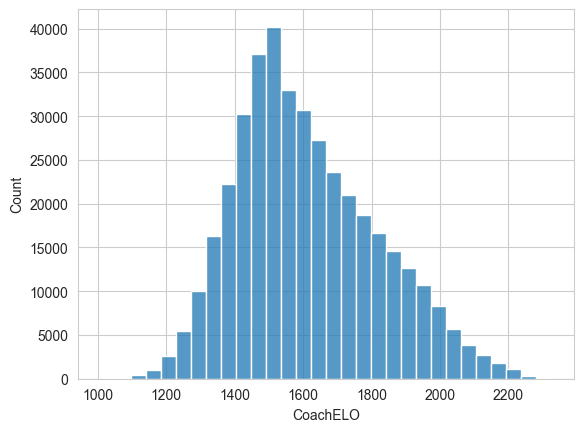

In [10]:
sns.histplot(elo_coach_df['CoachELO'], bins=30)

In [11]:
#best coaches in history ever
elo_coach_df.groupby('CoachName')['CoachELO'].max().sort_values(ascending=False).head(10)

CoachName
mark_few           2325.601307
tony_bennett       2309.966365
scott_drew         2293.638766
john_calipari      2292.641757
mike_krzyzewski    2273.233567
dan_hurley         2271.454154
bill_self          2269.661310
jay_wright         2266.502470
roy_williams       2262.627851
bo_ryan            2255.341448
Name: CoachELO, dtype: float64

In [12]:
elo_coach_df.sort_values(by='CoachELO', ascending=False).head(10)

,Season,DayNum,TeamID,CoachName,CoachELO
352623,2021,154,1211,mark_few,2325.601307
352620,2021,152,1211,mark_few,2320.353123
354443,2022,25,1211,mark_few,2317.756540
352614,2021,148,1211,mark_few,2314.596502
354156,2022,22,1211,mark_few,2311.807420
354042,2022,21,1211,mark_few,2310.982510
353696,2022,18,1211,mark_few,2310.620179
353316,2022,14,1211,mark_few,2310.447031
336401,2020,30,1438,tony_bennett,2309.966365
335856,2020,23,1438,tony_bennett,2309.861050


In [13]:
#take together elo for coaches and teams
elo_df = elo_df.merge(elo_coach_df, how='left', left_on=['Season', 'DayNum', 'TeamID'], right_on=['Season', 'DayNum', 'TeamID'])
elo_df

,Season,DayNum,TeamID,TeamELO,CoachName,CoachELO
0,1985,20,1228,1500.000000,lou_henson,1500.0
1,1985,20,1328,1500.000000,billy_tubbs,1500.0
2,1985,25,1106,1500.000000,james_oliver,1500.0
3,1985,25,1354,1500.000000,chico_caldwell,1500.0
4,1985,25,1112,1500.000000,lute_olson,1500.0
...,...,...,...,...,...,...
676021,2025,132,3119,1495.390030,NaN,NaN
676022,2025,132,3293,1721.291541,NaN,NaN
676023,2025,132,3125,1810.040382,NaN,NaN
676024,2025,132,3456,1394.728166,NaN,NaN


In [14]:
elo_df.to_csv(folder+'elo.csv', index=False)

In [15]:
# take only tournaments from 2010 to 2024
tournament = MenTournament[(MenTournament['Season'] >= 2010) & (MenTournament['Season'] <= 2024)]
tournament

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
1584,2010,134,1115,61,1457,44,N,0
1585,2010,136,1124,68,1358,59,N,0
1586,2010,136,1139,77,1431,59,N,0
1587,2010,136,1140,99,1196,92,N,2
1588,2010,136,1242,90,1250,74,N,0
...,...,...,...,...,...,...,...,...
2513,2024,146,1301,76,1181,64,N,0
2514,2024,146,1345,72,1397,66,N,0
2515,2024,152,1163,86,1104,72,N,0
2516,2024,152,1345,63,1301,50,N,0


In [16]:
# add elo here
tournament = tournament.merge(elo_df, how='left', left_on=['Season', 'DayNum', 'WTeamID'], right_on=['Season', 'DayNum', 'TeamID'], suffixes=('_W', '_L')).merge(elo_df, how='left', left_on=['Season', 'DayNum', 'LTeamID'], right_on=['Season', 'DayNum', 'TeamID'], suffixes=('_W', '_L'))
# take columns with TEAMIDs and ELOs
tournament = tournament[['Season', 'DayNum', 'WTeamID', 'LTeamID', 'TeamELO_W', 'TeamELO_L', 'CoachELO_W', 'CoachELO_L']]
tournament

,Season,DayNum,WTeamID,LTeamID,TeamELO_W,TeamELO_L,CoachELO_W,CoachELO_L
0,2010,134,1115,1457,1293.620328,1435.940191,1529.250804,1577.304377
1,2010,136,1124,1358,1936.132062,1607.953020,1982.513009,1727.454953
2,2010,136,1139,1431,1961.585673,1814.148420,2016.224664,1888.172286
3,2010,136,1140,1196,1914.299666,1850.299308,1970.388403,1913.918752
4,2010,136,1242,1250,2163.740204,1434.278730,2204.083246,1593.575625
...,...,...,...,...,...,...,...,...
959,2024,146,1301,1181,1933.996988,2041.214285,1962.356185,2027.939972
960,2024,146,1345,1397,2160.410542,2037.027527,2171.781559,2086.840863
961,2024,152,1163,1104,2213.596353,2018.940420,2249.103734,2068.951881
962,2024,152,1345,1301,2170.955939,1954.783539,2183.946010,1981.341062


In [17]:
#predict probability of winning
def predict_proba(A_elo, B_elo):
    return 1 / (1 + 10 ** ((B_elo - A_elo) / 400))

tournament['Pred'] = predict_proba(tournament['TeamELO_W'], tournament['TeamELO_L'])
tournament

,Season,DayNum,WTeamID,LTeamID,TeamELO_W,TeamELO_L,CoachELO_W,CoachELO_L,Pred
0,2010,134,1115,1457,1293.620328,1435.940191,1529.250804,1577.304377,0.305921
1,2010,136,1124,1358,1936.132062,1607.953020,1982.513009,1727.454953,0.868659
2,2010,136,1139,1431,1961.585673,1814.148420,2016.224664,1888.172286,0.700298
3,2010,136,1140,1196,1914.299666,1850.299308,1970.388403,1913.918752,0.591076
4,2010,136,1242,1250,2163.740204,1434.278730,2204.083246,1593.575625,0.985213
...,...,...,...,...,...,...,...,...,...
959,2024,146,1301,1181,1933.996988,2041.214285,1962.356185,2027.939972,0.350420
960,2024,146,1345,1397,2160.410542,2037.027527,2171.781559,2086.840863,0.670456
961,2024,152,1163,1104,2213.596353,2018.940420,2249.103734,2068.951881,0.754087
962,2024,152,1345,1301,2170.955939,1954.783539,2183.946010,1981.341062,0.776327


In [18]:
brier_score = ((tournament['Pred']-1) ** 2).mean()
print(f'Brier score: {brier_score}')

Brier score: 0.19306821691932632


In [19]:
#elo for coaches
tournament['Pred_Coach'] = predict_proba(tournament['CoachELO_W'], tournament['CoachELO_L'])
tournament

,Season,DayNum,WTeamID,LTeamID,TeamELO_W,TeamELO_L,CoachELO_W,CoachELO_L,Pred,Pred_Coach
0,2010,134,1115,1457,1293.620328,1435.940191,1529.250804,1577.304377,0.305921,0.431283
1,2010,136,1124,1358,1936.132062,1607.953020,1982.513009,1727.454953,0.868659,0.812789
2,2010,136,1139,1431,1961.585673,1814.148420,2016.224664,1888.172286,0.700298,0.676368
3,2010,136,1140,1196,1914.299666,1850.299308,1970.388403,1913.918752,0.591076,0.580558
4,2010,136,1242,1250,2163.740204,1434.278730,2204.083246,1593.575625,0.985213,0.971094
...,...,...,...,...,...,...,...,...,...,...
959,2024,146,1301,1181,1933.996988,2041.214285,1962.356185,2027.939972,0.350420,0.406723
960,2024,146,1345,1397,2160.410542,2037.027527,2171.781559,2086.840863,0.670456,0.619861
961,2024,152,1163,1104,2213.596353,2018.940420,2249.103734,2068.951881,0.754087,0.738278
962,2024,152,1345,1301,2170.955939,1954.783539,2183.946010,1981.341062,0.776327,0.762473


In [20]:
brier_score = ((tournament['Pred_Coach']-1) ** 2).mean()
print(f'Brier score: {brier_score}')

Brier score: 0.19503584693340942


In [21]:
#chciałbym iść po ramce danych od dołu do góry i dla danej drużyny przepisywać najbliższe Wartości ELo w górę
elo_df = elo_df.sort_values(by=['Season', 'DayNum', 'TeamID'])
elo_df

,Season,DayNum,TeamID,TeamELO,CoachName,CoachELO
0,1985,20,1228,1500.000000,lou_henson,1500.0
1,1985,20,1328,1500.000000,billy_tubbs,1500.0
2,1985,25,1106,1500.000000,james_oliver,1500.0
4,1985,25,1112,1500.000000,lute_olson,1500.0
17,1985,25,1133,1500.000000,dick_versace,1500.0
...,...,...,...,...,...,...
676018,2025,132,3192,1465.957795,NaN,NaN
676020,2025,132,3250,1561.941868,NaN,NaN
676022,2025,132,3293,1721.291541,NaN,NaN
676024,2025,132,3456,1394.728166,NaN,NaN


In [22]:
elo_ratings_coach

{'lou_henson': 1579.3196990187707,
 'billy_tubbs': 1514.0687171310697,
 'james_oliver': 1419.1915095672207,
 'chico_caldwell': 1355.1097139476576,
 'lute_olson': 1943.1993200011068,
 'gene_iba': 1549.3478237289323,
 'tom_miller': 1183.7968576347478,
 'larry_costello': 1344.4576922483245,
 'tom_green': 1283.5180069459288,
 'neil_kennett': 1294.7625198795595,
 'larry_little': 1454.6038654718056,
 'jim_harrick': 1973.8015158471712,
 'wayne_ballard': 1453.579657873071,
 'larry_brown': 2032.976831257315,
 'lefty_driesell': 1544.103006113689,
 'gene_sullivan': 1473.3937782106555,
 'dick_versace': 1796.9472651246012,
 'sonny_allen': 1519.9296542595348,
 'jerry_tarkanian': 1746.0094738068283,
 'gary_colson': 1646.307015406457,
 'thomas_dean': 1275.5469063322141,
 'nathaniel_mcmillian': 1280.3635215419524,
 'joseph_mullaney': 1438.7001824466347,
 'terry_holland': 1837.2372299617598,
 'dave_bliss': 1725.433035793525,
 'robert_moreland': 1211.5558456100464,
 'gene_bartow': 1667.6162060205997,
 'd

In [23]:
coaches[coaches['Season']==2025]

,Season,TeamID,FirstDayNum,LastDayNum,CoachName
13167,2025,1101,0,154,brette_tanner
13168,2025,1102,0,154,joe_scott
13169,2025,1103,0,154,john_groce
13170,2025,1104,0,154,nate_oats
13171,2025,1105,0,154,otis_hughley_jr
...,...,...,...,...,...
13528,2025,1476,0,154,chris_kraus
13529,2025,1477,0,154,jaret_von_rosenberg
13530,2025,1478,0,154,nate_champion
13531,2025,1479,0,154,gary_manchel


In [24]:
#create pandas DataFrame with elo ratings for coaches 
coaches_last_teamID = coaches[coaches['Season']==2025]
coaches_last_teamID = (coaches_last_teamID[coaches_last_teamID['LastDayNum']==154]).reset_index(drop=True)
coaches_last_teamID

,Season,TeamID,FirstDayNum,LastDayNum,CoachName
0,2025,1101,0,154,brette_tanner
1,2025,1102,0,154,joe_scott
2,2025,1103,0,154,john_groce
3,2025,1104,0,154,nate_oats
4,2025,1105,0,154,otis_hughley_jr
...,...,...,...,...,...
359,2025,1476,0,154,chris_kraus
360,2025,1477,0,154,jaret_von_rosenberg
361,2025,1478,0,154,nate_champion
362,2025,1479,0,154,gary_manchel


In [25]:
#df with elo ratings for coaches and teamids
elo_ratings_coach = pd.DataFrame(elo_ratings_coach.items(), columns=['CoachName', 'CoachELO'])
elo_ratings_coach = elo_ratings_coach.merge(coaches_last_teamID, how='left', left_on='CoachName', right_on='CoachName')
elo_ratings_coach = elo_ratings_coach[['Season', 'CoachName', 'CoachELO', 'TeamID']]
#remove rows with NaN
elo_ratings_coach = (elo_ratings_coach.dropna()).reset_index(drop=True)
elo_ratings_coach

,Season,CoachName,CoachELO,TeamID
0,2025.0,fran_mccaffery,1855.833027,1234.0
1,2025.0,rick_pitino,2143.617542,1385.0
2,2025.0,leonard_hamilton,1787.864123,1199.0
3,2025.0,rick_barnes,2129.903478,1397.0
4,2025.0,kelvin_sampson,2243.025621,1222.0
...,...,...,...,...
359,2025.0,craig_doty,1411.793198,1223.0
360,2025.0,paul_corsaro,1404.101904,1237.0
361,2025.0,cornelius_jackson,1613.177099,1267.0
362,2025.0,ethan_faulkner,1608.455994,1464.0


In [26]:
#save to csv: final_elo_coach.csv
elo_ratings_coach.to_csv(folder+'final_elo_coach.csv', index=False)

In [27]:

elo_ratings

{1228: 1976.446582057643,
 1328: 1865.209005118922,
 1106: 1235.9389817857773,
 1354: 1274.5047280817616,
 1112: 1992.0474206732813,
 1223: 1115.7863593901907,
 1165: 1568.3837302477775,
 1432: 1330.8979752531043,
 1192: 1239.2918221517637,
 1447: 1216.0428663021273,
 1218: 1440.9834126218173,
 1337: 1441.8732626638637,
 1226: 1350.6592644021955,
 1242: 1959.4953450336875,
 1268: 1958.2360818074246,
 1260: 1734.767553838368,
 1133: 1752.2501832704247,
 1305: 1698.294670256523,
 1424: 1724.1896353979498,
 1307: 1879.0667891536596,
 1288: 1148.3170436604435,
 1344: 1706.3244564473464,
 1438: 1761.290893229373,
 1374: 1809.0098638958061,
 1411: 1218.6440533761527,
 1412: 1735.28914697301,
 1397: 2072.4882785602945,
 1417: 1918.3101525863817,
 1225: 1296.8371551591908,
 1116: 1859.7959295859118,
 1368: 1287.3429076687246,
 1120: 2096.8310738911814,
 1391: 1253.1368923374707,
 1135: 1462.2269052716601,
 1306: 1233.5206772451145,
 1143: 1617.4833519214772,
 1388: 1979.3727271636412,
 1153: 1

In [28]:
#check all team id
team_ids = pd.concat([MenSeason['WTeamID'], MenSeason['LTeamID'], MenTournament['WTeamID'], MenTournament['LTeamID'], WomenSeason['WTeamID'], WomenSeason['LTeamID'], WomenTournament['WTeamID'], WomenTournament['LTeamID']])
team_ids = team_ids.unique()
team_ids = pd.DataFrame(team_ids, columns=['TeamID'])
team_ids.sort_values(by='TeamID')


,TeamID
363,1101
112,1102
134,1103
54,1104
327,1105
...,...
743,3476
744,3477
746,3478
748,3479


In [29]:
elo_ratings= pd.DataFrame(elo_ratings.items(), columns=['TeamID', 'TeamELO'])
#elo_ratings = elo_ratings.sort_values(by='TeamID')
elo_ratings

,TeamID,TeamELO
0,1228,1976.446582
1,1328,1865.209005
2,1106,1235.938982
3,1354,1274.504728
4,1112,1992.047421
...,...,...
744,1478,1155.979444
745,1479,1341.454910
746,1480,1258.946093
747,3480,1351.409092


In [30]:
#save to csv: final_elo_team.csv
elo_ratings.to_csv(folder+'final_elo_team.csv', index=False)

In [31]:
seasons = tournament['Season'].unique()

In [32]:
#crosswalidation
brier_score=[]

for season in seasons:
    only_this_season = tournament[tournament['Season']==season]
    brier_score.append(((only_this_season['Pred']-1) ** 2).mean())
print(f'Brier score: {np.mean(brier_score)}', f'Standard deviation: {np.std(brier_score)}')

Brier score: 0.19307355425963083 Standard deviation: 0.018928442580841184


In [33]:
#for coaches
brier_score=[]
for season in seasons:
    only_this_season = tournament[tournament['Season']==season]
    brier_score.append(((only_this_season['Pred_Coach']-1) ** 2).mean())
print(f'Brier score: {np.mean(brier_score)}', f'Standard deviation: {np.std(brier_score)}')

Brier score: 0.19486684649306027 Standard deviation: 0.017088561400360254


In [34]:
only_this_season = tournament[tournament['Season']==2024]
only_this_season

,Season,DayNum,WTeamID,LTeamID,TeamELO_W,TeamELO_L,CoachELO_W,CoachELO_L,Pred,Pred_Coach
897,2024,134,1161,1438,1766.448519,1931.965639,1865.132162,1960.057163,0.278323,0.366693
898,2024,134,1447,1224,1310.062646,1303.735312,1450.749909,1531.998198,0.509105,0.385160
899,2024,135,1160,1129,1871.734585,1834.194103,1953.752712,1921.706697,0.553816,0.545988
900,2024,135,1212,1286,1331.728720,1478.317547,1561.437890,1543.580009,0.300728,0.525677
901,2024,136,1112,1253,1993.065548,1519.232763,2049.325624,1663.688675,0.938636,0.902023
...,...,...,...,...,...,...,...,...,...,...
959,2024,146,1301,1181,1933.996988,2041.214285,1962.356185,2027.939972,0.350420,0.406723
960,2024,146,1345,1397,2160.410542,2037.027527,2171.781559,2086.840863,0.670456,0.619861
961,2024,152,1163,1104,2213.596353,2018.940420,2249.103734,2068.951881,0.754087,0.738278
962,2024,152,1345,1301,2170.955939,1954.783539,2183.946010,1981.341062,0.776327,0.762473


### Mean of prediction based on Elo for Teams and Elo for Coaches
#### check which ks is the best

In [35]:
tournament

,Season,DayNum,WTeamID,LTeamID,TeamELO_W,TeamELO_L,CoachELO_W,CoachELO_L,Pred,Pred_Coach
0,2010,134,1115,1457,1293.620328,1435.940191,1529.250804,1577.304377,0.305921,0.431283
1,2010,136,1124,1358,1936.132062,1607.953020,1982.513009,1727.454953,0.868659,0.812789
2,2010,136,1139,1431,1961.585673,1814.148420,2016.224664,1888.172286,0.700298,0.676368
3,2010,136,1140,1196,1914.299666,1850.299308,1970.388403,1913.918752,0.591076,0.580558
4,2010,136,1242,1250,2163.740204,1434.278730,2204.083246,1593.575625,0.985213,0.971094
...,...,...,...,...,...,...,...,...,...,...
959,2024,146,1301,1181,1933.996988,2041.214285,1962.356185,2027.939972,0.350420,0.406723
960,2024,146,1345,1397,2160.410542,2037.027527,2171.781559,2086.840863,0.670456,0.619861
961,2024,152,1163,1104,2213.596353,2018.940420,2249.103734,2068.951881,0.754087,0.738278
962,2024,152,1345,1301,2170.955939,1954.783539,2183.946010,1981.341062,0.776327,0.762473


In [36]:
tournament['Pred_combined'] = (tournament['Pred'] + tournament['Pred_Coach'])/2
tournament

,Season,DayNum,WTeamID,LTeamID,TeamELO_W,TeamELO_L,CoachELO_W,CoachELO_L,Pred,Pred_Coach,Pred_combined
0,2010,134,1115,1457,1293.620328,1435.940191,1529.250804,1577.304377,0.305921,0.431283,0.368602
1,2010,136,1124,1358,1936.132062,1607.953020,1982.513009,1727.454953,0.868659,0.812789,0.840724
2,2010,136,1139,1431,1961.585673,1814.148420,2016.224664,1888.172286,0.700298,0.676368,0.688333
3,2010,136,1140,1196,1914.299666,1850.299308,1970.388403,1913.918752,0.591076,0.580558,0.585817
4,2010,136,1242,1250,2163.740204,1434.278730,2204.083246,1593.575625,0.985213,0.971094,0.978153
...,...,...,...,...,...,...,...,...,...,...,...
959,2024,146,1301,1181,1933.996988,2041.214285,1962.356185,2027.939972,0.350420,0.406723,0.378571
960,2024,146,1345,1397,2160.410542,2037.027527,2171.781559,2086.840863,0.670456,0.619861,0.645159
961,2024,152,1163,1104,2213.596353,2018.940420,2249.103734,2068.951881,0.754087,0.738278,0.746182
962,2024,152,1345,1301,2170.955939,1954.783539,2183.946010,1981.341062,0.776327,0.762473,0.769400


In [37]:
brier_score = ((tournament['Pred_combined']-1) ** 2).mean()
print(f'Brier score: {brier_score}')

Brier score: 0.19287197406575574


In [38]:
#crosswalidation
brier_score=[]
for season in seasons:
    only_this_season = tournament[tournament['Season']==season]
    only_this_season['Pred_combined'] = (only_this_season['Pred'] + only_this_season['Pred_Coach'])/2
    brier_score.append(((only_this_season['Pred_combined']-1) ** 2).mean())
print(f'Brier score: {np.mean(brier_score)}', f'Standard deviation: {np.std(brier_score)}')

Brier score: 0.19281834055043592 Standard deviation: 0.017502593308493374


/var/folders/7q/jtsqqb2j4bj4j9t6p9c76vw00000gn/T/ipykernel_33836/167361507.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_this_season['Pred_combined'] = (only_this_season['Pred'] + only_this_season['Pred_Coach'])/2


In [39]:
ks = [i for i in range(10, 41)]
ks

[10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40]

In [ ]:
brier_score = []
brier_score_std = []
ks = [i for i in range(10, 41)]
for k in ks:
    elo_ratings = {}
    elo_df = calculate_elo(df, k=k)
    elo_ratings_coach = {}
    elo_coach_df = calculate_coach_elo(matchups, k=k)
    elo_df = elo_df.merge(elo_coach_df, how='left', left_on=['Season', 'DayNum', 'TeamID'], right_on=['Season', 'DayNum', 'TeamID'])
    tournament = MenTournament[(MenTournament['Season'] >= 2010) & (MenTournament['Season'] <= 2024)]
    tournament = tournament.merge(elo_df, how='left', left_on=['Season', 'DayNum', 'WTeamID'], right_on=['Season', 'DayNum', 'TeamID'], suffixes=('_W', '_L')).merge(elo_df, how='left', left_on=['Season', 'DayNum', 'LTeamID'], right_on=['Season', 'DayNum', 'TeamID'], suffixes=('_W', '_L'))
    tournament = tournament[['Season', 'DayNum', 'WTeamID', 'LTeamID', 'TeamELO_W', 'TeamELO_L', 'CoachELO_W', 'CoachELO_L']]
    tournament['Pred'] = predict_proba(tournament['TeamELO_W'], tournament['TeamELO_L'])
    tournament['Pred_Coach'] = predict_proba(tournament['CoachELO_W'], tournament['CoachELO_L'])
    tournament['Pred_combined'] = (tournament['Pred'] + tournament['Pred_Coach'])/2
    brier_score_temp=[]
    for season in seasons:
        only_this_season = tournament[tournament['Season']==season]
        brier_score_temp.append(((only_this_season['Pred_combined']-1) ** 2).mean())
    brier_score.append(np.mean(brier_score_temp))
    brier_score_std.append(np.std(brier_score_temp))

In [ ]:
plt.plot(ks, brier_score)
plt.xlabel('k')
plt.ylabel('Brier score')
plt.title('Brier score for different k')
plt.show()

In [ ]:
brier_score

In [ ]:
# which k?
ks[np.argmin(brier_score)]

### The best k is 32

In [ ]:
brier_score_std

In [ ]:
ks[np.argmin(brier_score_std)]

In [ ]:
plt.plot(ks, brier_score_std)
plt.xlabel('k')
plt.ylabel('Brier score std')
plt.title('Brier score std for different k')
plt.show()

In [ ]:
tournament['brier'] = (tournament['Pred_combined']-1) ** 2
tournament

In [ ]:
tournament.sort_values(by='brier', ascending=False)

In [ ]:
#create 
sns.scatterplot(data=tournament[tournament['brier']>0.40], x='Season', y='brier')
plt.show()